In [4]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize BigQuery client
# Option A: If using keyfile.json (Codespaces)
# client = bigquery.Client.from_service_account_json(
#    'keyfile.json', 
#    project='mythic-fulcrum-509507-k0', 
#    location='EU'
#)

# Option B: If authenticated via gcloud CLI
client = bigquery.Client(project='mythic-fulcrum-509507-k0', location='EU')

# Query top 10 origin-destination routes from your Star Schema
query = """
    SELECT 
        s1.station_name AS start_station,
        s2.station_name AS end_station,
        COUNT(f.rental_id) AS total_trips,
        ROUND(AVG(f.duration_minutes), 2) AS avg_duration_min
    FROM `mythic-fulcrum-509507-k0.dbt_london_bicycles.FactTrips` f
    JOIN `mythic-fulcrum-509507-k0.dbt_london_bicycles.DimStation` s1 
        ON f.start_station_id = s1.station_id
    JOIN `mythic-fulcrum-509507-k0.dbt_london_bicycles.DimStation` s2 
        ON f.end_station_id = s2.station_id
    GROUP BY 1, 2
    ORDER BY total_trips DESC
    LIMIT 10
"""

df_routes = client.query(query).to_dataframe()
print("Top 10 Most Popular Commuter Routes:")
print(df_routes)

Top 10 Most Popular Commuter Routes:
                                  start_station  \
0                   Hyde Park Corner, Hyde Park   
1  Aquatic Centre, Queen Elizabeth Olympic Park   
2                        Albert Gate, Hyde Park   
3           Black Lion Gate, Kensington Gardens   
4                  Triangle Car Park, Hyde Park   
5                         Park Lane , Hyde Park   
6          Podium, Queen Elizabeth Olympic Park   
7               Palace Gate, Kensington Gardens   
8                    Wellington Arch, Hyde Park   
9                   Hyde Park Corner, Hyde Park   

                                    end_station  total_trips  avg_duration_min  
0                   Hyde Park Corner, Hyde Park       156846             51.98  
1  Aquatic Centre, Queen Elizabeth Olympic Park       127559             58.68  
2                        Albert Gate, Hyde Park        86195             46.12  
3           Black Lion Gate, Kensington Gardens        83255             51.9

In [ ]:
plt.figure(figsize=(12, 6))
df_routes['route'] = df_routes['start_station'] + ' ➔ ' + df_routes['end_station']

sns.barplot(data=df_routes, x='total_trips', y='route', palette='Blues_r')
plt.title('Top 10 Most Popular London Bicycle Routes', fontsize=14, fontweight='bold')
plt.xlabel('Total Rental Trips', fontsize=12)
plt.ylabel('Route (Start ➔ End)', fontsize=12)
plt.tight_layout()
plt.show()

/home/boonc/miniconda3/envs/bde/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


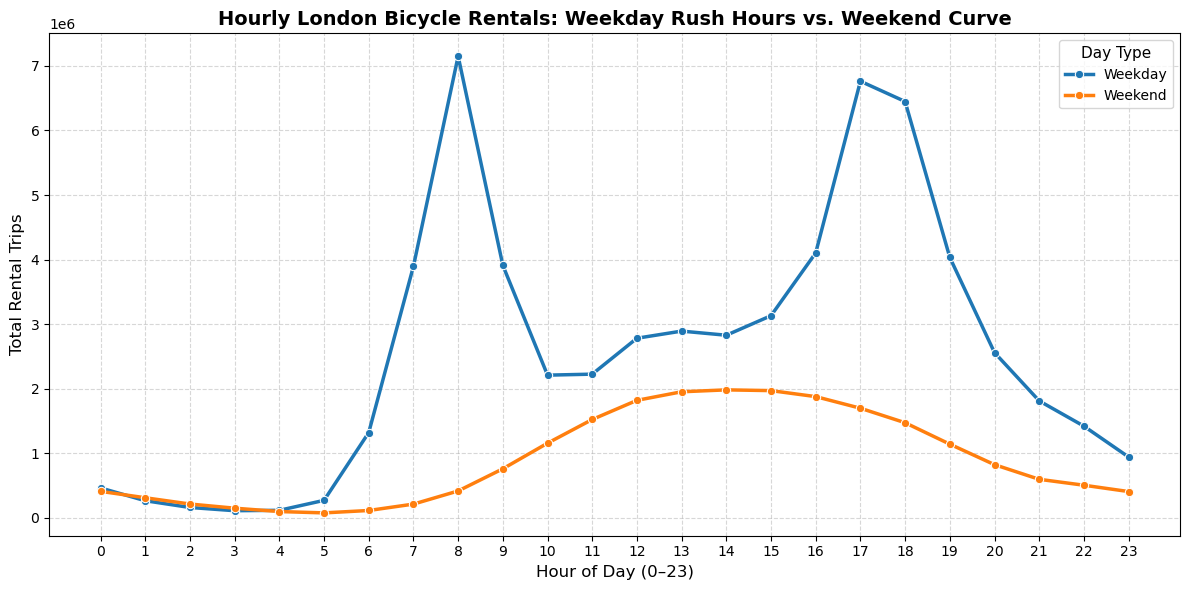

In [ ]:
# Query hourly trip distribution by weekday vs weekend
query_hourly = """
    SELECT 
        f.start_hour,
        d.is_weekend,
        COUNT(f.rental_id) AS total_trips
    FROM `mythic-fulcrum-509507-k0.dbt_london_bicycles.FactTrips` f
    JOIN `mythic-fulcrum-509507-k0.dbt_london_bicycles.DimDate` d 
        ON f.start_date_id = d.date_id
    GROUP BY 1, 2
    ORDER BY 1, 2
"""

df_hourly = client.query(query_hourly).to_dataframe()

# Label weekend status for plot legend
df_hourly['day_type'] = df_hourly['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

# Plotting Hourly Trends
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_hourly, 
    x='start_hour', 
    y='total_trips', 
    hue='day_type', 
    marker='o', 
    linewidth=2.5,
    palette={'Weekday': '#1f77b4', 'Weekend': '#ff7f0e'}
)

plt.title('Hourly London Bicycle Rentals: Weekday Rush Hours vs. Weekend Curve', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Total Rental Trips', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Day Type', title_fontsize='11')
plt.tight_layout()
plt.show()

# Result: Weekday peaks at 08:00 AM and 17:00 PM vs. weekend midday

/home/boonc/miniconda3/envs/bde/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


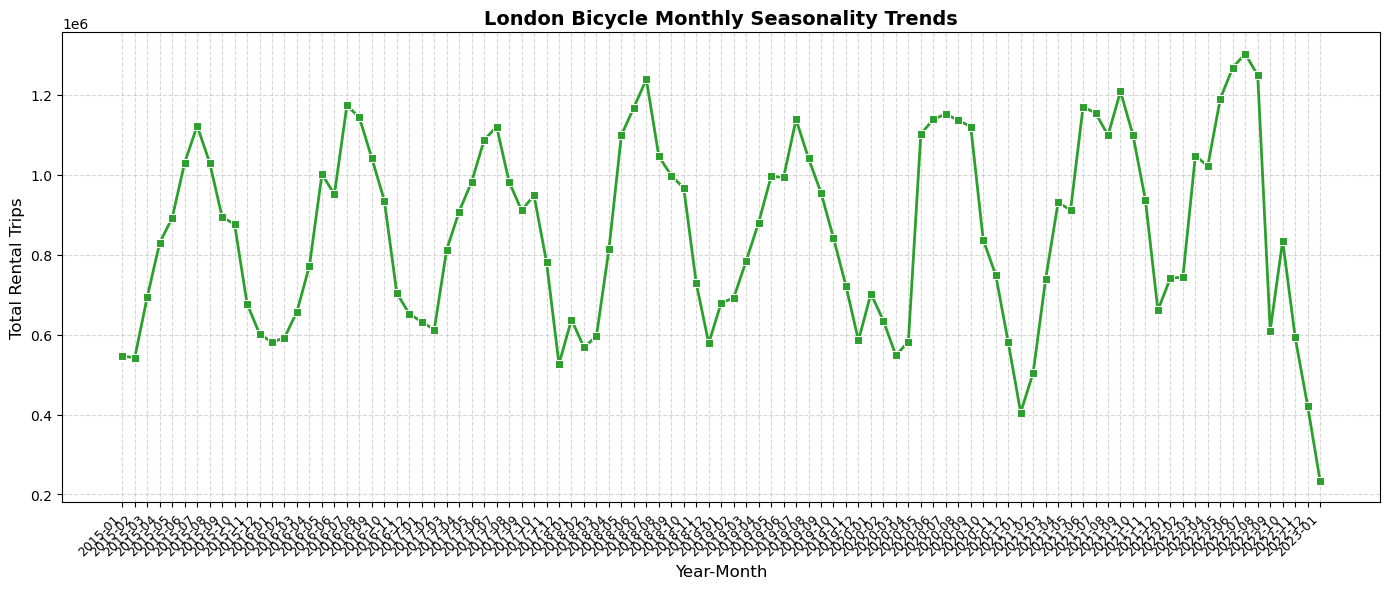

In [ ]:
# Query monthly volume trends over time
query_monthly = """
    SELECT 
        d.year,
        d.month,
        d.month_name,
        COUNT(f.rental_id) AS total_trips
    FROM `mythic-fulcrum-509507-k0.dbt_london_bicycles.FactTrips` f
    JOIN `mythic-fulcrum-509507-k0.dbt_london_bicycles.DimDate` d 
        ON f.start_date_id = d.date_id
    GROUP BY 1, 2, 3
    ORDER BY d.year, d.month
"""

df_monthly = client.query(query_monthly).to_dataframe()

# Format Year-Month label for x-axis
df_monthly['year_month'] = df_monthly['year'].astype(str) + '-' + df_monthly['month'].astype(str).str.zfill(2)

# Plotting Monthly Seasonality
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_monthly, x='year_month', y='total_trips', marker='s', color='#2ca02c', linewidth=2)

plt.title('London Bicycle Monthly Seasonality Trends', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Rental Trips', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Result: Peak summer usage (July–August) vs. winter drop-off